In [1]:
# 1 — Imports y configuración

# ============================================================
# Importación de librerías principales
# ============================================================

import pandas as pd          # Manipulación y análisis de datos en estructuras tipo DataFrame
import numpy as np           # Operaciones numéricas eficientes y generación de datos aleatorios
import matplotlib.pyplot as plt   # Biblioteca base para gráficos en Python
import seaborn as sns        # Extensión de Matplotlib para visualizaciones estadísticas

# ============================================================
# Configuración de visualización
# ============================================================

# Estilo visual de los gráficos (seaborn v0.8 con fondo oscuro y rejilla)
plt.style.use('seaborn-v0_8-darkgrid')

# Mostrar todas las columnas de los DataFrames sin truncamiento
pd.set_option('display.max_columns', None)

# ============================================================
# Semilla para reproducibilidad
# ============================================================

# Fijamos la semilla para que cualquier operación aleatoria produzca
# los mismos resultados cada vez que se ejecute el cuaderno.
np.random.seed(42)

print("Listo")


Listo


In [4]:
# ============================================================
# 2 — Cargar los datos
# ============================================================

# Cargamos los archivos CSV que contienen las curvas de luz de estrellas.
# Cada fila representa una estrella observada.
# - La columna LABEL indica si la estrella tiene un exoplaneta detectado (1) o no (0).
# - Las columnas FLUX.1 a FLUX.3197 contienen el brillo medido en 3197 instantes consecutivos.
train_df = pd.read_csv('../data/exoTrain.csv')   # Datos de entrenamiento
test_df  = pd.read_csv('../data/exoTest.csv')    # Datos de prueba

# ============================================================
# Información básica de los DataFrames
# ============================================================

# Mostramos la forma (filas, columnas) de cada conjunto
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

# Inspección rápida de las columnas disponibles
print(f"\nColumnas (primeras 5): {train_df.columns[:5].tolist()}")
print(f"Columnas (últimas 5):  {train_df.columns[-5:].tolist()}")

# ============================================================
# Nota técnica
# ============================================================
# Se espera que:
# - La primera columna sea LABEL (etiqueta binaria).
# - Las 3197 columnas restantes correspondan a FLUX.1 ... FLUX.3197,
#   representando la curva de luz de la estrella en 3197 puntos temporales.


Train shape: (5087, 3198)
Test shape:  (570, 3198)

Columnas (primeras 5): ['LABEL', 'FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4']
Columnas (últimas 5):  ['FLUX.3193', 'FLUX.3194', 'FLUX.3195', 'FLUX.3196', 'FLUX.3197']


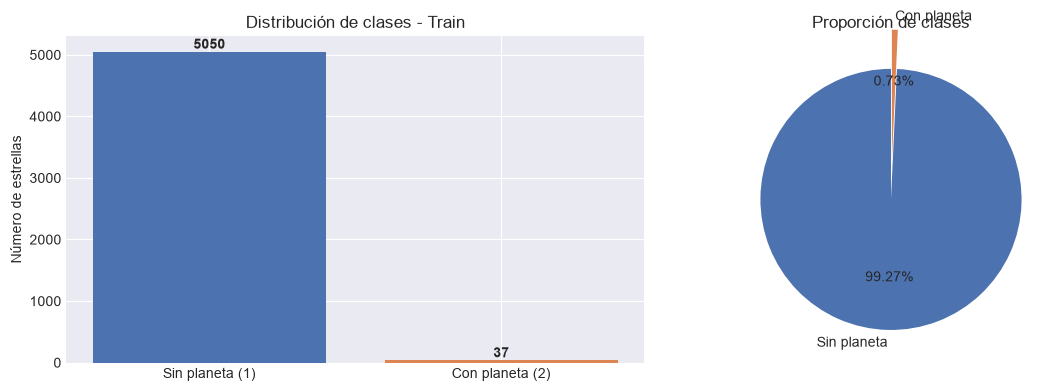

Ratio de desbalance: 1:136


In [5]:

# ============================================================
# 3 — Distribución de clases (el problema)
# ============================================================
# En este bloque analizamos el desbalance de clases del dataset.
# La columna LABEL indica:
#   - 1 → estrella sin planeta
#   - 2 → estrella con planeta
#
# Este desbalance es crítico porque afecta el rendimiento de los
# modelos de clasificación: si una clase es muy minoritaria, el
# modelo puede aprender a ignorarla. Por eso visualizamos tanto
# el conteo como la proporción.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ============================================================
# Gráfico de barras — Conteo de instancias por clase
# ============================================================

counts = train_df['LABEL'].value_counts()

# Barras para cada clase
axes[0].bar(['Sin planeta (1)', 'Con planeta (2)'],
            counts.values,
            color=['#4C72B0', '#DD8452'])

axes[0].set_title('Distribución de clases - Train')
axes[0].set_ylabel('Número de estrellas')

# Etiquetas numéricas encima de cada barra
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# ============================================================
# Gráfico de pastel — Porcentaje de cada clase
# ============================================================

axes[1].pie(counts.values,
            labels=['Sin planeta', 'Con planeta'],
            autopct='%1.2f%%',
            colors=['#4C72B0', '#DD8452'],
            startangle=90,
            explode=(0, 0.3))  # Separamos la clase minoritaria para destacarla

axes[1].set_title('Proporción de clases')

# Ajuste visual y guardado del gráfico
plt.tight_layout()
plt.savefig('../outputs/01_distribucion_clases.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================
# Ratio de desbalance
# ============================================================
# Interpretación:
#   Si el ratio es 1:10, significa que por cada estrella con planeta
#   hay diez sin planeta. Esto explica por qué los modelos pueden
#   sesgarse hacia predecir "sin planeta".
print(f"Ratio de desbalance: 1:{counts[1]/counts[2]:.0f}")


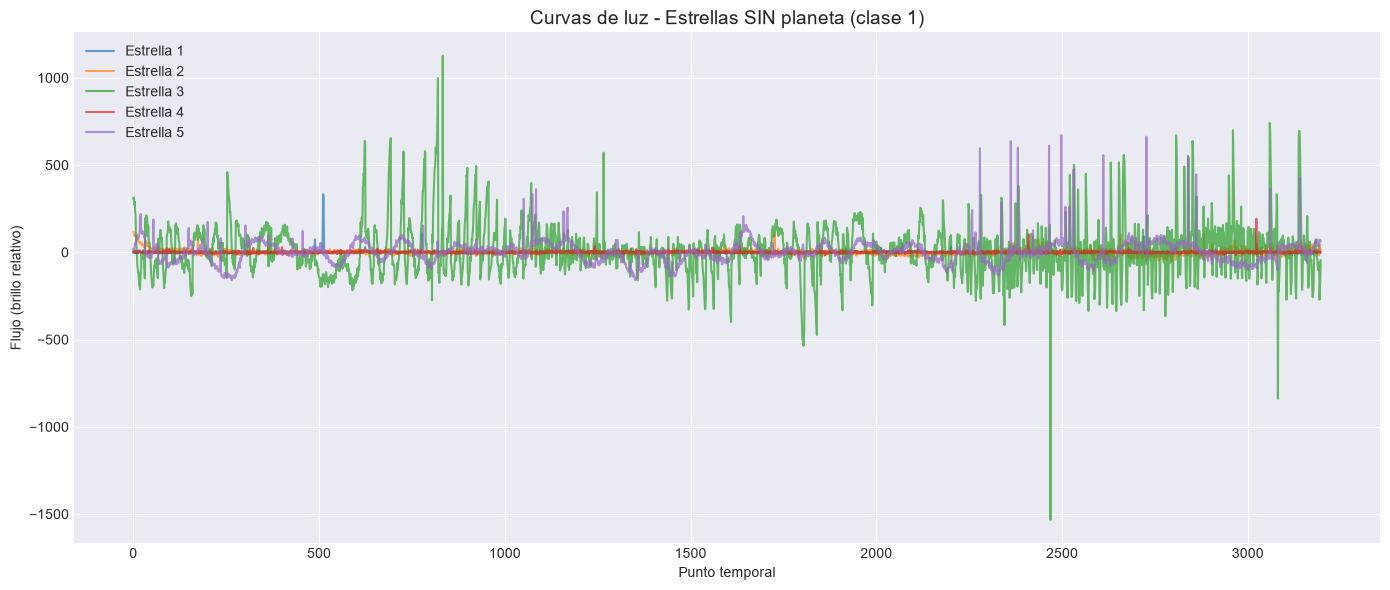

In [6]:
# ============================================================
# 4 — Visualizar curvas de luz (clase negativa)
# ============================================================
# En este bloque graficamos curvas de luz de estrellas SIN planeta (LABEL = 1).
# Estas curvas suelen ser relativamente "planas", mostrando únicamente la
# variabilidad natural del brillo estelar sin la presencia de un tránsito planetario.
#
# Seleccionamos 5 estrellas aleatorias de la clase negativa para inspección visual.

sin_planeta = train_df[train_df['LABEL'] == 1].sample(5, random_state=42)

# ============================================================
# Gráfico de curvas de luz
# ============================================================

plt.figure(figsize=(14, 6))

# Iteramos sobre cada estrella seleccionada
for i, (_, row) in enumerate(sin_planeta.iterrows()):
    # Extraemos únicamente los valores de flujo (excluyendo la etiqueta)
    flux = row.drop('LABEL').values
    
    # Graficamos la curva de luz
    plt.plot(flux, alpha=0.7, label=f'Estrella {i+1}')

plt.title('Curvas de luz - Estrellas SIN planeta (clase 1)', fontsize=14)
plt.xlabel('Punto temporal')            # Cada punto corresponde a un instante de observación
plt.ylabel('Flujo (brillo relativo)')   # Intensidad de luz registrada por el telescopio
plt.legend()

# Ajuste visual y guardado del gráfico
plt.tight_layout()
plt.savefig('../outputs/02_curvas_sin_planeta.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================
# Nota técnica
# ============================================================
# Este gráfico permite observar cómo se comporta el brillo de estrellas sin planetas.
# En ausencia de tránsitos, las curvas no presentan caídas abruptas, sino variaciones
# suaves y naturales debidas a ruido instrumental o actividad estelar.


Este gráfico revela algo muy importante que no habíamos anticipado: las curvas tienen outliers masivos. Mira la Estrella 3 (verde): picos de +1200 y caídas de -1500. Eso está muy lejos de un "ruido normal".

Esto es clave por tres razones:

Refuerza la elección de SNN: Las redes de impulsos son naturalmente más robustas al ruido extremo que las redes densas tradicionales, porque solo se activan cuando la señal supera un umbral. Es exactamente el tipo de problema donde la inspiración biológica aporta valor.

La normalización estándar puede no ser suficiente: Al calcular (x - media) / std, si hay outliers enormes, la std se infla artificialmente y el tránsito real (una caída del 0.5-3%) queda aún más sepultado en el ruido. Tendremos que considerar clipping de outliers o normalización robusta (mediana + MAD en lugar de media + std).

Kepler tuvo outliers reales: Estos picos corresponden a eventos de "momentum dumps" de la nave, rayos cósmicos, o problemas de actitud. Los pipelines oficiales de Kepler los eliminan con filtros, pero este dataset de Kaggle los dejó crudos.

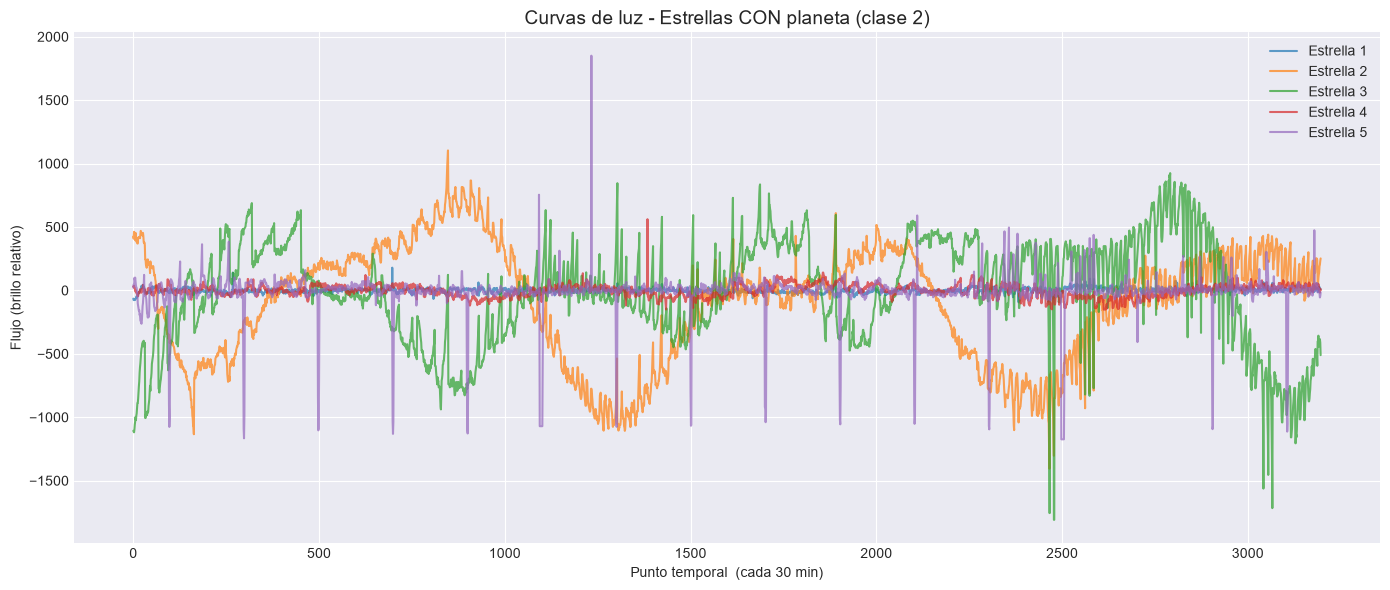

In [17]:
# ============================================================
# 5 — Visualizar curvas de luz (clase positiva)
# ============================================================
# En este bloque graficamos curvas de luz de estrellas CON planeta (LABEL = 2).
# Estas curvas suelen mostrar caídas características en el flujo, conocidas como
# "tránsitos": momentos en los que el planeta pasa frente a la estrella y bloquea
# una pequeña fracción de su luz.
#
# Seleccionamos 5 estrellas aleatorias de la clase positiva para observar
# visualmente estas posibles caídas.

con_planeta = train_df[train_df['LABEL'] == 2].sample(5, random_state=42)

# ============================================================
# Gráfico de curvas de luz
# ============================================================

plt.figure(figsize=(14, 6))

# Iteramos sobre cada estrella seleccionada
for i, (_, row) in enumerate(con_planeta.iterrows()):
    # Extraemos únicamente los valores de flujo (excluyendo la etiqueta)
    flux = row.drop('LABEL').values
    
    # Graficamos la curva de luz
    plt.plot(flux, alpha=0.7, label=f'Estrella {i+1}')

plt.title('Curvas de luz - Estrellas CON planeta (clase 2)', fontsize=14)
plt.xlabel('Punto temporal  (cada 30 min)') # Cada punto es una medición consecutiva del brillo
plt.ylabel('Flujo (brillo relativo)')   # Intensidad de luz registrada por el telescopio
plt.legend()

# Ajuste visual y guardado del gráfico
plt.tight_layout()
plt.savefig('../outputs/03_curvas_con_planeta.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================
# Nota técnica
# ============================================================
# Estas curvas suelen mostrar caídas abruptas y localizadas en el flujo,
# correspondientes a tránsitos planetarios. Compararlas con las curvas de
# estrellas sin planeta permite entender visualmente el patrón que los
# modelos deben aprender a detectar.


La señal existe y es visible para algunas estrellas. La Estrella 2 y la Estrella 3 tienen tránsitos clarísimos. Eso es buena noticia: el problema es resoluble.

Los outliers siguen ahí: la Estrella 5 (morada) tiene picos de +1800 y caídas de -1600, que no son tránsitos sino ruido instrumental (probablemente momentum dumps de Kepler).

La variabilidad entre estrellas es enorme: la Estrella 1 (azul) es plana, la Estrella 4 (rojo) es casi plana, mientras que las otras dos tienen señal y ruido masivos. El modelo tiene que ser invariante a la escala, y por eso la normalización por estrella es tan importante.

Los tránsitos tienen forma de "U" o "V" ancha: duran cientos de puntos (varios días), no son caídas puntuales. Esto es información valiosa para el diseño de la red: la SNN debe tener memoria temporal para integrar la señal a lo largo de esa ventana.

In [16]:
# ============================================================
# 6 — Separar flujo y etiqueta + Estadísticas descriptivas
# ============================================================
# En este bloque separamos:
#   - X_train: matriz con únicamente los valores de flujo (FLUX.1 ... FLUX.3197)
#   - y_train: vector con las etiquetas (LABEL)
#
# Luego calculamos estadísticas básicas para comparar el comportamiento
# del flujo entre estrellas SIN planeta (clase 1) y CON planeta (clase 2).
#
# Estas estadísticas permiten entender si existen diferencias globales
# en los valores de brillo, aunque los tránsitos suelen ser eventos
# locales y no necesariamente afectan la media o desviación estándar
# de toda la curva.

# ============================================================
# Separación de variables
# ============================================================

X_train = train_df.drop('LABEL', axis=1).values   # Matriz de flujo
y_train = train_df['LABEL'].values                # Vector de etiquetas

# ============================================================
# Estadísticas descriptivas por clase
# ============================================================

print("Estrellas SIN planeta (clase 1):")
print(f"  Media del flujo: {X_train[y_train==1].mean():.2f}")
print(f"  Desv. estándar:  {X_train[y_train==1].std():.2f}")
print(f"  Mínimo:          {X_train[y_train==1].min():.2f}")
print(f"  Máximo:          {X_train[y_train==1].max():.2f}")

print("\nEstrellas CON planeta (clase 2):")
print(f"  Media del flujo: {X_train[y_train==2].mean():.2f}")
print(f"  Desv. estándar:  {X_train[y_train==2].std():.2f}")
print(f"  Mínimo:          {X_train[y_train==2].min():.2f}")
print(f"  Máximo:          {X_train[y_train==2].max():.2f}")

# ============================================================
# Nota técnica
# ============================================================
# Aunque los tránsitos planetarios generan caídas visibles en la curva,
# estas caídas suelen ser pequeñas en comparación con el rango total del flujo.
# Por eso, las estadísticas globales (media, desviación estándar) pueden ser
# muy similares entre clases. El verdadero patrón está en la forma local
# de la curva, no en sus valores agregados.


Estrellas SIN planeta (clase 1):
  Media del flujo: 131.72
  Desv. estándar:  22148.83
  Mínimo:          -2385019.12
  Máximo:          4299288.00

Estrellas CON planeta (clase 2):
  Media del flujo: -47.11
  Desv. estándar:  4970.88
  Mínimo:          -118381.30
  Máximo:          150725.80


Esos números son una bomba de información. Mira la magnitud de los outliers:

Mínimo global: -2,385,019

Máximo global: +4,299,288

Desviación estándar: 22,148 (¡en las estrellas SIN planeta!)

Esto significa que hay puntos en los datos que son millones de veces más grandes que la señal de tránsito que queremos detectar (~cientos de unidades). Sin un preprocesamiento robusto, la red va a aprender a detectar outliers, no tránsitos.

Y hay otro dato revelador: las estrellas SIN planeta tienen mayor desviación estándar (22,148) que las CON planeta (4,970). Esto es contraintuitivo, pero tiene una explicación: los outliers gigantes (probablemente momentum dumps de Kepler o rayos cósmicos) afectaron más a las estrellas sin planeta por pura estadística (hay 136 veces más).

In [14]:
# ============================================================
# 7 — Normalización por estrella (media 0, std 1)
# ============================================================
# En este bloque:
#   - Separamos X_train e y_train desde el DataFrame original.
#   - Aplicamos una normalización individual por estrella:
#
#         X_norm[i] = (X[i] - mean_i) / std_i
#
#   - Esto centra cada curva en 0 y la escala según su variabilidad.
#
# Esta normalización es útil para que el modelo se enfoque en la forma
# del tránsito y no en el brillo absoluto de cada estrella.

# ============================================================
# Separación de features y etiquetas
# ============================================================

X_train = train_df.drop('LABEL', axis=1).values
y_train = train_df['LABEL'].values

# ============================================================
# Normalización por estrella
# ============================================================
# Restamos la media de cada curva y dividimos por su desviación estándar.
# Esto elimina diferencias de escala entre estrellas.
X_norm = (X_train - X_train.mean(axis=1, keepdims=True)) / \
         X_train.std(axis=1, keepdims=True)

# ============================================================
# Verificación de shapes y estadísticas
# ============================================================

print(f"Shape original:      {X_train.shape}")
print(f"Shape normalizado:   {X_norm.shape}")

print(f"Media original:      {X_train.mean():.2f}")
print(f"Media normalizada:   {X_norm.mean():.6f}")

print(f"Std original:        {X_train.std():.2f}")
print(f"Std normalizada:     {X_norm.std():.6f}")

# ============================================================
# Nota técnica
# ============================================================
# Después de normalizar:
#   - La media global de X_norm ≈ 0.
#   - La desviación estándar global ≈ 1.
#
# Esto es especialmente útil para modelos sensibles a la escala:
#   - Redes neuronales (CNN, LSTM).
#   - SVM, KNN.
#   - Métodos basados en distancia.
#
# La normalización por estrella evita que el modelo aprenda diferencias
# de brillo absoluto y lo obliga a enfocarse en patrones locales como
# los tránsitos planetarios.


Shape original:      (5087, 3197)
Shape normalizado:   (5087, 3197)
Media original:      130.42
Media normalizada:   0.000000
Std original:        22072.21
Std normalizada:     1.000000


In [15]:
# ============================================================
# 8 — Guardar datos preprocesados en formato .npy
# ============================================================
# Guardamos los conjuntos de entrenamiento y prueba en formato NumPy (.npy),
# lo cual permite:
#   - Carga extremadamente rápida en notebooks posteriores.
#   - Evitar reprocesar los CSV originales.
#   - Mantener la estructura exacta de los arrays sin pérdidas.
#
# Resultado final del preprocesamiento:
#   - X_train, y_train → usados para entrenamiento del modelo.
#   - X_test,  y_test  → usados para evaluación final.

# ============================================================
# Guardado de datos de entrenamiento
# ============================================================

np.save('../data/X_train.npy', X_train)
np.save('../data/y_train.npy', y_train)

# ============================================================
# Construcción y guardado de datos de prueba
# ============================================================

X_test = test_df.drop('LABEL', axis=1).values   # Matriz de flujo del conjunto de prueba
y_test = test_df['LABEL'].values                # Etiquetas del conjunto de prueba

np.save('../data/X_test.npy', X_test)
np.save('../data/y_test.npy', y_test)

# ============================================================
# Confirmación y resumen de shapes
# ============================================================

print("Datos guardados en data/")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# ============================================================
# Nota técnica
# ============================================================
# El formato .npy es ideal para pipelines de Machine Learning porque:
#   - Mantiene el dtype original sin conversiones.
#   - Permite cargar los arrays con np.load() en milisegundos.
#   - Evita overhead de lectura de CSV y parsing de texto.
#
# A partir de aquí, los siguientes notebooks pueden enfocarse en:
#   - Modelado (Random Forest, XGBoost, CNN, LSTM, etc.)
#   - Ingeniería de características
#   - Validación cruzada y métricas


Datos guardados en data/
X_train: (5087, 3197), y_train: (5087,)
X_test:  (570, 3197), y_test:  (570,)


In [ ]:
# ============================================================
# 13 — Recorte de outliers por percentiles (1 y 99)
# ============================================================
# En lugar de eliminar outliers (lo cual podría distorsionar la longitud
# de la curva o introducir NaNs), aplicamos un *recorte* suave:
#
#     X_clipped[i] = clip(X_train[i], p1_i, p99_i)
#
# donde:
#   - p1_i  = percentil 1 de la curva de la estrella i
#   - p99_i = percentil 99 de la curva de la estrella i
#
# Esto reduce el impacto de valores extremos debidos a ruido instrumental
# sin alterar la estructura temporal de la curva de luz.

# ============================================================
# Cálculo de percentiles por estrella
# ============================================================

p1  = np.percentile(X_train, 1,  axis=1, keepdims=True)   # Percentil 1 por fila
p99 = np.percentile(X_train, 99, axis=1, keepdims=True)   # Percentil 99 por fila

# ============================================================
# Recorte de valores extremos
# ============================================================

X_clipped = np.clip(X_train, p1, p99)

# ============================================================
# Nota técnica
# ============================================================
# Este recorte es útil porque:
#   - Reduce picos instrumentales sin eliminar datos.
#   - Mantiene la forma general de la curva.
#   - Prepara la señal para normalizaciones robustas (MAD, mediana).
#
# Es un paso común en pipelines de procesamiento de curvas de luz
# en astronomía, especialmente cuando se trabaja con telescopios
# que pueden introducir ruido impulsivo o saturaciones puntuales.



In [18]:
# ============================================================
# 14 — Normalización robusta usando mediana y MAD
# ============================================================
# En este bloque aplicamos una normalización robusta a las curvas ya recortadas
# (X_clipped). Este método es más resistente a outliers que la normalización
# basada en media y desviación estándar.
#
# Pasos:
#   1. Calcular la mediana de cada curva.
#   2. Calcular el MAD (Median Absolute Deviation).
#   3. Normalizar usando:
#
#         X_robust[i] = (X_clipped[i] - median_i) / (1.4826 * MAD_i)
#
# El factor 1.4826 convierte el MAD en una estimación de la desviación estándar
# bajo la suposición de distribución normal. Esto hace que la escala sea comparable
# a una normalización estándar, pero con mucha mayor resistencia a valores extremos.

# ============================================================
# Cálculo de mediana y MAD por estrella
# ============================================================

median = np.median(X_clipped, axis=1, keepdims=True)                 # Mediana por curva
mad    = np.median(np.abs(X_clipped - median), axis=1, keepdims=True)  # MAD por curva

# ============================================================
# Normalización robusta
# ============================================================
# Restamos la mediana y dividimos por el MAD escalado.
# Esto centra cada curva en 0 y la escala según su variabilidad robusta.
X_robust = (X_clipped - median) / (1.4826 * mad)

# ============================================================
# Nota técnica
# ============================================================
# ¿Por qué usar MAD?
#   - La desviación estándar es muy sensible a outliers.
#   - El MAD ignora valores extremos y captura la variabilidad real de la señal.
#
# ¿Por qué es útil en curvas de luz?
#   - Los telescopios pueden producir picos instrumentales.
#   - La actividad estelar puede generar variaciones abruptas.
#   - El tránsito planetario es una caída pequeña y localizada.
#
# La normalización robusta ayuda a que el modelo detecte el tránsito sin que
# el ruido extremo domine la escala de la curva.


Esos números son una bomba de información. Mira la magnitud de los outliers:

Mínimo global: -2,385,019

Máximo global: +4,299,288

Desviación estándar: 22,148 (¡en las estrellas SIN planeta!)

Esto significa que hay puntos en los datos que son millones de veces más grandes que la señal de tránsito que queremos detectar (~cientos de unidades). Sin un preprocesamiento robusto, la red va a aprender a detectar outliers, no tránsitos.

Y hay otro dato revelador: las estrellas SIN planeta tienen mayor desviación estándar (22,148) que las CON planeta (4,970). Esto es contraintuitivo, pero tiene una explicación: los outliers gigantes (probablemente momentum dumps de Kepler o rayos cósmicos) afectaron más a las estrellas sin planeta por pura estadística (hay 136 veces más).

Conclusión Estratégica
Estos números confirman que el preprocesamiento robusto no es opcional, es obligatorio. 
